In [57]:
import pandas as pd
import numpy as np

# Read data
df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv")
df = df.rename(columns={"index_nsa": "hpi"})

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_38663/2486126317.py:5: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv")


In [58]:
# Define hazard and financial predictors
climate_financial_vars = [
    "flood_frequency",
    "flood_property_damage",
    "flood_duration_hours",
    "heat_stress_index",
    "drought_annual_mean_index",
    "fire_frequency",
    "fire_size",
    "deaths_hurricane",
    "injuries_hurricane",
    "damage_hurricane",
    "real_gdp",
    "unemployment_rate",
    "prop_rate",
    "total_home_purchase",
    "total_amt_purchase",
    "total_population"
]

In [59]:
# Keep the columns of interest
columns_to_keep = ["county_fips5", "yr", "hpi", "flood_frequency", "flood_property_damage", "flood_duration_hours", "heat_stress_index",
"drought_annual_mean_index", "fire_frequency", "fire_size", "deaths_hurricane", "injuries_hurricane", "damage_hurricane", "real_gdp",
"unemployment_rate", "prop_rate", "total_home_purchase", "total_amt_purchase", "total_population"]
df = df[columns_to_keep]
df[climate_financial_vars] = df[climate_financial_vars].replace(["(NA)", "NA", ""], np.nan)

In [60]:
from sklearn.preprocessing import StandardScaler

# Create lag 1 HPI
df = df.sort_values(["county_fips5", "yr"])
df["hpi_lag1"] = df.groupby("county_fips5")["hpi"].shift(1)
df_lagged = df.dropna(subset=["hpi_lag1"]).reset_index(drop=True)

# Standarize the variables with scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_lagged[climate_financial_vars])
df_scaled = pd.DataFrame(X_scaled, columns=climate_financial_vars, index=df_lagged.index)

df_lagged = pd.concat([df_lagged, df_scaled], axis=1)

In [61]:
import bambi as bmb
import arviz as az

# Create a copy for modeling
df_lagged_bayes = df_lagged.copy()
df_lagged_bayes = df_lagged_bayes.loc[
    :, ~df_lagged_bayes.columns.duplicated(keep="last")
]

# Double check everything is in scaled form
for col in climate_financial_vars:
    df_lagged_bayes[col] = df_scaled[col]

df_lagged_bayes = df_lagged_bayes.dropna().reset_index(drop=True)
df_lagged_bayes["hpi_lag1_scaled"] = StandardScaler().fit_transform(df_lagged_bayes[["hpi_lag1"]])

formula_fe = "hpi ~ hpi_lag1_scaled + " + " + ".join(climate_financial_vars)

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Split data
df_early = df_lagged_bayes[df_lagged_bayes["yr"].between(2000, 2007)]
df_late = df_lagged_bayes[df_lagged_bayes["yr"].between(2013, 2019)]

In [63]:
# Early period model
model_early = bmb.Model(formula=formula_fe, data=df_early)
idata_early = model_early.fit(draws=1000, tune=1000)

# Late period model
model_late = bmb.Model(formula=formula_fe, data=df_late)
idata_late = model_late.fit(draws=1000, tune=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, hpi_lag1_scaled, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, deaths_hurricane, injuries_hurricane, damage_hurricane, real_gdp, unemployment_rate, prop_rate, total_home_purchase, total_amt_purchase, total_population]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 26 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, hpi_lag1_scaled, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, deaths_hurricane, injuries_hurricane, damage_hurricane, real_gdp, unemployment_rate, prop_rate, total_home_purchase, total_amt_purchase, total_population]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 42 seconds.


In [64]:
# Combine all the predictors
vars_all = ["hpi_lag1_scaled"] + climate_financial_vars

# Extra summaries for early and late periods
summary_early = az.summary(idata_early, var_names=vars_all, hdi_prob=0.95)
summary_late = az.summary(idata_late, var_names=vars_all, hdi_prob=0.95)

# Add tags to make it more clearer
summary_early["period"] = "2000-2006"
summary_late["period"] = "2012-2019"

# Add index names
summary_early["variable"] = summary_early.index
summary_late["variable"] = summary_late.index

# combine the summaries
summary_all = pd.concat([summary_early, summary_late], axis=0)

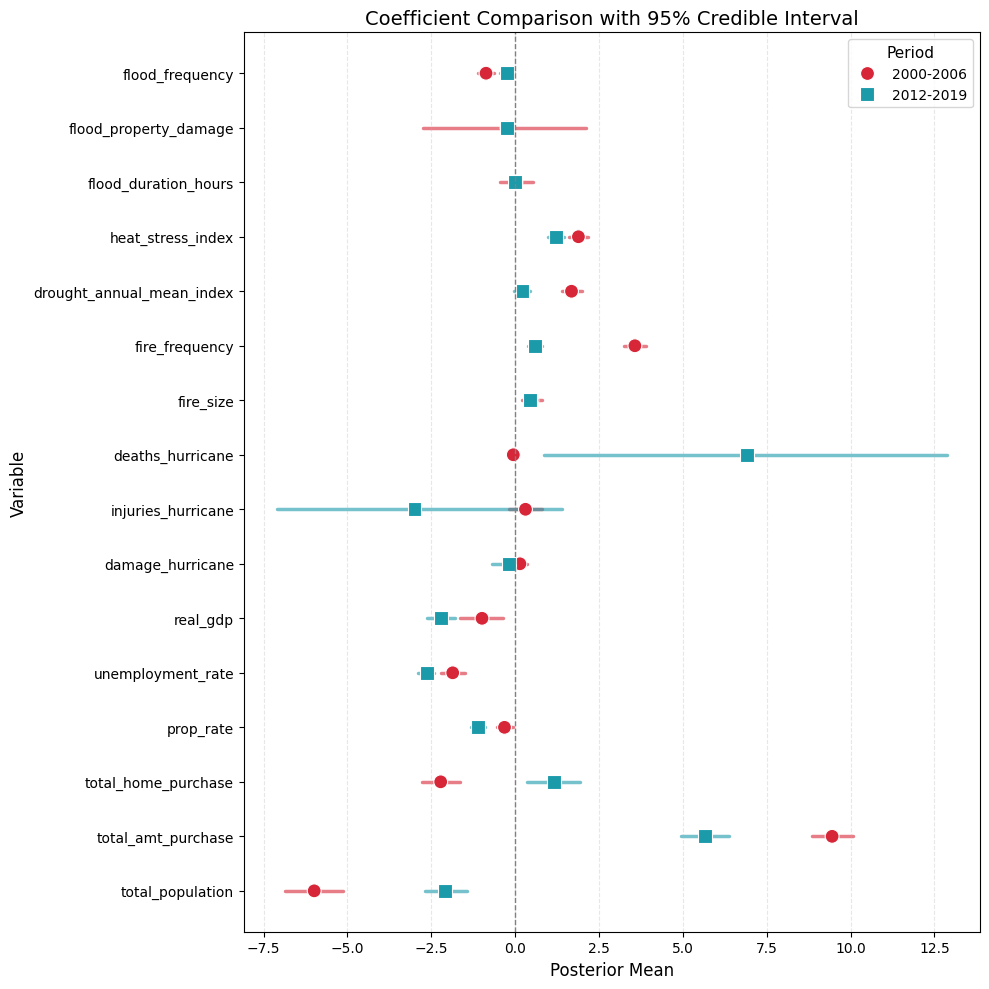

In [65]:
plt.figure(figsize=(10, 10))
summary_predictors = summary_all[summary_all["variable"] != "hpi_lag1_scaled"].copy()

# 重新排序变量以便读图
summary_predictors["variable"] = pd.Categorical(
    summary_predictors["variable"],
    categories=summary_predictors[summary_predictors["period"] == "2012-2019"]
        .sort_values("mean")["variable"],
    ordered=True
)

# 点图（先画底层的误差线）
for i, row in summary_predictors.iterrows():
    color = "#D72638" if row["period"] == "2000-2006" else "#1B9AAA"
    plt.plot(
        [row["hdi_2.5%"], row["hdi_97.5%"]],
        [row["variable"], row["variable"]],
        color=color,
        linewidth=2.5,
        alpha=0.6,
        solid_capstyle='round',
        zorder=1  # CI放在底层
    )

# 再画上点
sns.scatterplot(
    data=summary_predictors,
    x="mean", y="variable", hue="period",
    palette={"2000-2006": "#D72638", "2012-2019": "#1B9AAA"},
    style="period", markers=["o", "s"], s=100, zorder=2  # 大点点，覆盖在线上面
)

# 辅助线
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Coefficient Comparison with 95% Credible Interval", fontsize=14)
plt.xlabel("Posterior Mean", fontsize=12)
plt.ylabel("Variable", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Period", fontsize=10, title_fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 用idata_early滚动预测2013–2019
rolling_preds = []

# 初始年份：2012
baseline_2012 = df_lagged_bayes[df_lagged_bayes["yr"] == 2012].copy()

for year in range(2013, 2020):
    # 使用 bmb 的 predict()
    preds = model_early.predict(idata=idata_early, data=baseline_2012, kind="mean")
    
    # 存储预测结果
    baseline_2012["predicted_hpi"] = preds
    baseline_2012["yr"] = year
    rolling_preds.append(baseline_2012[["county_fips5", "yr", "predicted_hpi"]].copy())

    # 为下一年做准备
    next_year_data = df_lagged_bayes[df_lagged_bayes["yr"] == year].copy()
    next_year_data["hpi_lag1_scaled"] = (preds - df_lagged_bayes["hpi_lag1"].mean()) / df_lagged_bayes["hpi_lag1"].std()
    
    baseline_2012 = next_year_data


In [134]:
# Read data
df_2021_2024 = pd.read_csv("../../02_processed_data/hpi_county_2021_2024.csv")
df_2021_2024 = df_2021_2024.rename(columns={"index_nsa": "hpi"})

In [135]:
# 拼接成新的df（带2021-2024的HPI）
df_extended = pd.concat([df_lagged_bayes, df_2021_2024], axis=0, ignore_index=True)
df_extended = df_extended.sort_values(by=["county_fips5", "yr"]).reset_index(drop=True)

df_extended["hpi_lag1"] = df_extended.groupby("county_fips5")["hpi"].shift(1)

In [136]:
from sklearn.linear_model import LinearRegression

def forecast_variable(df, var_name, year_start=2000, year_end=2020, forecast_year=2023):
    preds = []

    for fips in df['county_fips5'].unique():
        df_sub = df[(df['county_fips5'] == fips) & 
                    (df['yr'].between(year_start, year_end))]

        # 需要足够多数据
        if df_sub.shape[0] < 3 or df_sub[var_name].isna().sum() > 0:
            continue
        
        X = df_sub['yr'].values.reshape(-1, 1)
        y = df_sub[var_name].values
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(np.array([[forecast_year]]))[0]

        preds.append({
            'county_fips5': fips,
            'yr': forecast_year,
            var_name: y_pred
        })
    
    return pd.DataFrame(preds)

In [137]:
df_all = df_lagged_bayes[["county_fips5", "yr"] + climate_financial_vars].copy()
forecast_list = []

for var in climate_financial_vars:
    df_pred = forecast_variable(df_all, var_name=var)
    forecast_list.append(df_pred)

# 合并所有预测列
from functools import reduce
df_2023_preds = reduce(lambda left, right: pd.merge(left, right, on=['county_fips5', 'yr'], how='outer'), forecast_list)

In [138]:
df_2023_final = df_2023_preds.merge(
    df_extended[df_extended["yr"] == 2023][["county_fips5", "hpi_lag1"]],
    on="county_fips5",
    how="left"
)
df_2023_final["yr"] = 2023

In [139]:
from sklearn.preprocessing import StandardScaler
scaler_hpi = StandardScaler()

# 标准化 predictors
df_2023_final[climate_financial_vars] = scaler.transform(
    df_2023_final[climate_financial_vars]
)

# 标准化 hpi_lag1
df_2023_final["hpi_lag1_scaled"] = scaler_hpi.fit_transform(df_2023_final[["hpi_lag1"]])

In [143]:
idata_pred_2024 = model_baseline.predict(
    idata=idata_baseline,
    data=df_2023_final,
    kind="mean",
    inplace=False
)

# 取出预测值
y_pred_2024 = (
    idata_pred_2024.posterior["mu"]
    .mean(dim=("chain", "draw"))
    .values
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:843: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(


In [144]:
# 真实 2024 的 HPI
df_2024_truth = df_2021_2024[df_2021_2024["yr"] == 2024][["county_fips5", "hpi"]].copy()
df_2024_truth = df_2024_truth.rename(columns={"hpi": "actual_2024"})

# 整合预测结果
df_compare = df_2023_final[["county_fips5"]].copy()
df_compare["pred_2024"] = y_pred_2024

# 合并真值
df_compare = df_compare.merge(df_2024_truth, on="county_fips5", how="left")


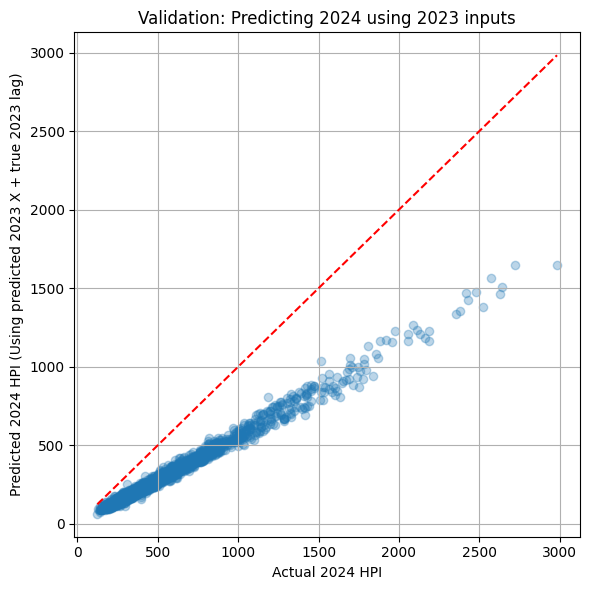

In [145]:
# 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df_compare["actual_2024"], df_compare["pred_2024"], alpha=0.3)
plt.plot(
    [df_compare["actual_2024"].min(), df_compare["actual_2024"].max()],
    [df_compare["actual_2024"].min(), df_compare["actual_2024"].max()],
    color="red", linestyle="--"
)
plt.xlabel("Actual 2024 HPI")
plt.ylabel("Predicted 2024 HPI (Using predicted 2023 X + true 2023 lag)")
plt.title("Validation: Predicting 2024 using 2023 inputs")
plt.grid(True)
plt.tight_layout()
plt.show()


In [123]:
df_pred_summary = pd.DataFrame({
    "county_fips5": df_2024_final["county_fips5"].values,
    "pred_mean": pred_mean,
    "pred_lower": pred_lower,
    "pred_upper": pred_upper
})

In [124]:
df_true_2024 = df_2021_2024[df_2021_2024["yr"] == 2024][["county_fips5", "hpi"]]

df_compare = df_pred_summary.merge(df_true_2024, on="county_fips5", how="left")
df_compare = df_compare.dropna(subset=["hpi"])

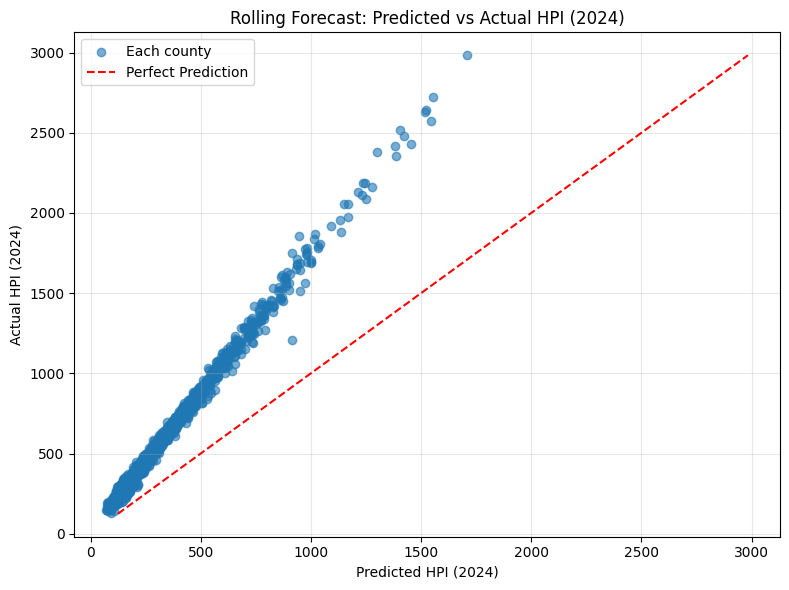

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_compare["pred_mean"], df_compare["hpi"], alpha=0.6, label="Each county")
plt.plot(
    [df_compare["hpi"].min(), df_compare["hpi"].max()],
    [df_compare["hpi"].min(), df_compare["hpi"].max()],
    color='red', linestyle='--', label='Perfect Prediction'
)

plt.xlabel("Predicted HPI (2024)")
plt.ylabel("Actual HPI (2024)")
plt.title("Rolling Forecast: Predicted vs Actual HPI (2024)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

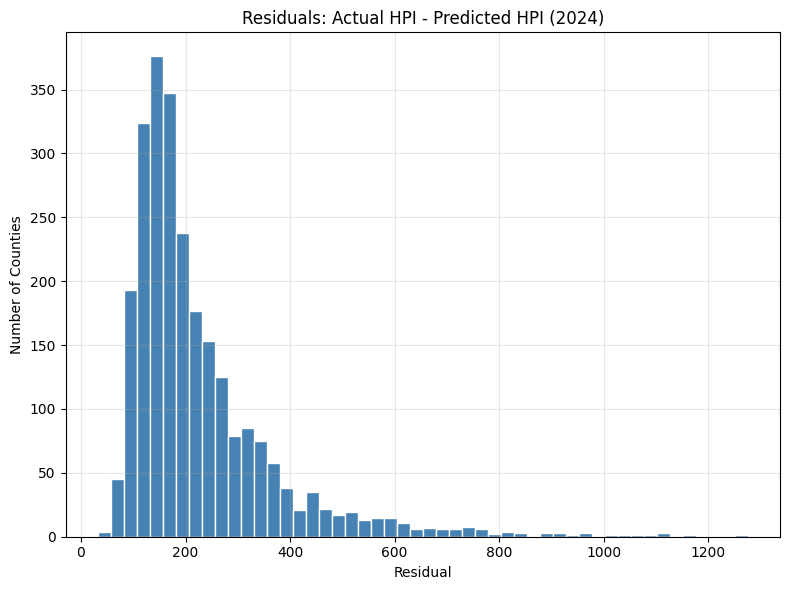

In [126]:
df_compare["residual"] = df_compare["hpi"] - df_compare["pred_mean"]

plt.figure(figsize=(8, 6))
plt.hist(df_compare["residual"], bins=50, color='steelblue', edgecolor='white')
plt.title("Residuals: Actual HPI - Predicted HPI (2024)")
plt.xlabel("Residual")
plt.ylabel("Number of Counties")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [127]:
df_lagged_bayes["hpi"].describe()

count    54454.000000
mean       268.474428
std        186.116692
min          0.000000
25%        158.140000
50%        209.535000
75%        313.515000
max       2577.170000
Name: hpi, dtype: float64

In [132]:
df_2023 = df_predictors[df_predictors["yr"] == 2023].copy()

df_2023 = df_2023.merge(
    df_hpi[df_hpi["yr"] == 2023][["county_fips5", "hpi"]],
    on="county_fips5",
    how="left"
).rename(columns={"hpi": "hpi_lag1"})

NameError: name 'df_predictors' is not defined

In [133]:
df_all

,county_fips5,yr,flood_frequency,flood_property_damage,flood_duration_hours,heat_stress_index,drought_annual_mean_index,fire_frequency,fire_size,deaths_hurricane,injuries_hurricane,damage_hurricane,real_gdp,unemployment_rate,prop_rate,total_home_purchase,total_amt_purchase,total_population
0,1001,2001,-0.362241,-0.020647,-0.159121,-0.134150,0.522775,-0.407714,-0.102149,-0.007695,-0.005949,-0.029647,-0.205206,-0.784615,-0.957797,-0.130366,-0.183813,-0.200927
1,1001,2002,-0.489481,-0.021012,-0.169839,0.525164,-0.542524,-0.407714,-0.102149,-0.007695,-0.005949,-0.029647,-0.203672,-0.517333,-0.957797,-0.138567,-0.177834,-0.197902
2,1001,2003,-0.362241,-0.020440,-0.154708,-0.278130,0.989755,0.357987,-0.083460,-0.007695,-0.005949,-0.029647,-0.202437,-0.440966,-0.710371,-0.114647,-0.165458,-0.195260
3,1001,2004,-0.425861,-0.020933,-0.161013,0.780930,-0.172831,1.123688,-0.051517,-0.007695,-0.005949,-0.029647,-0.195653,-0.555516,-0.710371,-0.098017,-0.150008,-0.190616
4,1001,2005,-0.107762,-0.020825,0.021815,-0.229956,0.264963,0.714127,-0.086221,-0.007695,-0.005949,-0.029647,-0.195117,-0.899164,-0.710371,-0.062933,-0.132041,-0.186731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54449,56045,2016,-0.489481,-0.021012,-0.169839,1.005560,-1.277045,0.197724,0.086581,-0.007695,-0.005949,-0.029647,-0.235036,-0.440966,-0.957797,-0.299175,-0.241826,-0.312608
54450,56045,2017,-0.489481,-0.021012,-0.169839,0.119288,-0.814929,0.179917,-0.095593,-0.007695,-0.005949,-0.029647,-0.235017,-0.784615,-0.957797,-0.288924,-0.235660,-0.313397
54451,56045,2018,-0.425861,-0.021012,-0.068767,-1.331716,1.972360,-0.140609,-0.095559,-0.007695,-0.005949,-0.029647,-0.234660,-1.013714,-0.957797,-0.294847,-0.238999,-0.313596
54452,56045,2019,-0.235001,-0.020667,-0.097338,-1.018010,3.276014,-0.176223,-0.095821,-0.007695,-0.005949,-0.029647,-0.234293,-1.204630,-0.957797,-0.293252,-0.235901,-0.313640


In [129]:
df_2024_input = df_2023.copy()
df_2024_input["yr"] = 2024   # 预测目标年
df_2024_input["hpi_lag1"] = df_2023["hpi"]  # 真实 2023 HPI

KeyError: 'hpi'

In [ ]:
# climate & financial X
df_2024_input[climate_financial_vars] = scaler.transform(
    df_2024_input[climate_financial_vars]
)

# hpi lag
df_2024_input["hpi_lag1_scaled"] = scaler_hpi.transform(
    df_2024_input[["hpi_lag1"]]
)

In [ ]:
idata_pred_2024 = model_baseline.predict(
    idata=idata_baseline,
    data=df_2024_input,
    kind="mean",     
    inplace=False
)

In [ ]:
y_pred_2024 = (
    idata_pred_2024.posterior["mean"]
    .mean(dim=("chain", "draw"))
    .values
)

In [ ]:
df_compare = pd.DataFrame({
    "county_fips5": df_2024_input["county_fips5"].values,
    "pred_2024": y_pred_2024,
})

df_compare = df_compare.merge(
    df_2024_real[["county_fips5", "hpi"]],
    on="county_fips5",
    how="left"
).rename(columns={"hpi": "actual_2024"})